1. Đang trích xuất Ma trận Không gian...
2. Đang nạp Ký ức Không gian - Thời gian (Spatio-Temporal) cho TỪNG kịch bản...


Xử lý Không gian edge_dataset_kb1.csv: 100%|██████████| 981762/981762 [00:10<00:00, 90173.55it/s] 


Xử lý Thời gian edge_dataset_kb1.csv...


Xử lý Không gian edge_dataset_kb2.csv: 100%|██████████| 19900/19900 [00:00<00:00, 70049.51it/s]


Xử lý Thời gian edge_dataset_kb2.csv...


Xử lý Không gian edge_dataset_kb3.csv: 100%|██████████| 70866/70866 [00:00<00:00, 114983.16it/s]


Xử lý Thời gian edge_dataset_kb3.csv...


Xử lý Không gian edge_dataset_kb4.csv: 100%|██████████| 1980/1980 [00:00<00:00, 110059.00it/s]


Xử lý Thời gian edge_dataset_kb4.csv...
3. Hợp nhất Siêu dữ liệu AI...
4. Huấn luyện hệ thống VEEPS hoàn chỉnh...

5. BÁO CÁO KẾT QUẢ CHUNG CUỘC:
MAE  : 0.0095
MSE  : 0.0016
RMSE : 0.0404
R^2  : 0.7356


<Figure size 900x600 with 0 Axes>

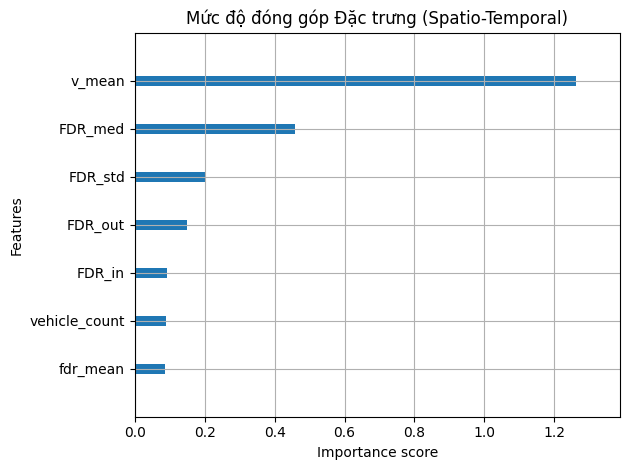

In [10]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import xml.etree.ElementTree as ET
from tqdm import tqdm

print("1. Đang trích xuất Ma trận Không gian...")
def build_network_topology(net_xml_path):
    tree = ET.parse(net_xml_path)
    root = tree.getroot()
    incoming, outgoing = {}, {}
    for conn in root.findall('connection'):
        from_edge, to_edge = conn.get('from'), conn.get('to')
        from_lane_idx, to_lane_idx = conn.get('fromLane'), conn.get('toLane')
        if not (from_edge and to_edge and from_lane_idx and to_lane_idx): continue
        from_lane = f"{from_edge}_{from_lane_idx}"
        to_lane = f"{to_edge}_{to_lane_idx}"
        outgoing.setdefault(from_lane, []).append(to_lane)
        incoming.setdefault(to_lane, []).append(from_lane)
    return incoming, outgoing

incoming_map, outgoing_map = build_network_topology('osm.net.xml')

print("2. Đang nạp Ký ức Không gian - Thời gian (Spatio-Temporal) cho TỪNG kịch bản...")
def process_full_and_split(file_name, predict_window=60):
    df = pd.read_csv(file_name)
    df['SPI'] = (df['v_mean'] / 14.0).clip(0.0, 1.0)
    fdr_lookup = df.set_index(['timestep', 'lane_id'])['fdr_mean'].to_dict()

    def get_adjacent_fdr(row, adj_map):
        t, current_lane = row['timestep'], row['lane_id']
        neighbors = adj_map.get(current_lane, [])
        if not neighbors: return 1.0
        fdr_sum, count = 0, 0
        for n in neighbors:
            key = (t, n)
            if key in fdr_lookup:
                fdr_sum += fdr_lookup[key]
                count += 1
        return fdr_sum / count if count > 0 else 1.0

    # Kỹ thuật Không gian (Spatial)
    tqdm.pandas(desc=f"Xử lý Không gian {file_name}")
    df['FDR_in'] = df.progress_apply(lambda r: get_adjacent_fdr(r, incoming_map), axis=1)
    df['FDR_out'] = df.progress_apply(lambda r: get_adjacent_fdr(r, outgoing_map), axis=1)

    # Kỹ thuật Thời gian (Temporal) - Ký ức 5 phút (300 giây)
    print(f"Xử lý Thời gian {file_name}...")
    df = df.sort_values(by=['lane_id', 'timestep'])
    df['FDR_med'] = df.groupby('lane_id')['fdr_mean'].transform(lambda x: x.rolling(300, min_periods=1).median())
    df['FDR_std'] = df.groupby('lane_id')['fdr_mean'].transform(lambda x: x.rolling(300, min_periods=1).std().fillna(0))

    # Dự đoán Tương lai và Cắt tập
    df['future_SPI'] = df.groupby('lane_id')['SPI'].shift(-predict_window)
    df = df.dropna(subset=['future_SPI'])

    df = df.sort_values(by=['timestep'])
    split_idx = int(len(df) * 0.8)
    return df.iloc[:split_idx], df.iloc[split_idx:]

train1, test1 = process_full_and_split('edge_dataset_kb1.csv')
train2, test2 = process_full_and_split('edge_dataset_kb2.csv')
train3, test3 = process_full_and_split('edge_dataset_kb3.csv')
train4, test4 = process_full_and_split('edge_dataset_kb4.csv')

print("3. Hợp nhất dữ liệu")
train_df = pd.concat([train1, train2, train3, train4], ignore_index=True)
test_df = pd.concat([test1, test2, test3, test4], ignore_index=True)

# THÊM 2 ĐẶC TRƯNG THỜI GIAN VÀO MÔ HÌNH
features = ['vehicle_count', 'v_mean', 'fdr_mean', 'FDR_in', 'FDR_out', 'FDR_med', 'FDR_std']
X_train, y_train = train_df[features], train_df['future_SPI']
X_test, y_test = test_df[features], test_df['future_SPI']

print("4. Huấn luyện hệ thống VEEPS hoàn chỉnh...")
model = xgb.XGBRegressor(
    n_estimators=512,
    max_depth=10,
    learning_rate=0.05,
    random_state=42,
    eval_metric='rmse'
)
model.fit(X_train, y_train)

print("\n5. BÁO CÁO KẾT QUẢ:")
y_pred = model.predict(X_test)
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R^2  : {r2_score(y_test, y_pred):.4f}")

plt.figure(figsize=(9, 6))
xgb.plot_importance(model, importance_type='gain', show_values=False, title='Mức độ đóng góp Đặc trưng (Spatio-Temporal)')
plt.tight_layout()
plt.show()